<a href="https://colab.research.google.com/github/BBCharming/CS/blob/master/CS351/CS351Week0Lab1_ipynb_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## CS351 Numerical Analysis
  **SIN: 23138696**\
  **NAME: Benjamin Chaambwa**\
  **LAB: 1. Floating-Point Arithmetic
in Practice**\
  **WEEK: 1**\
  **DUE: Friday 20th March, 2026 at 11.59.pm**

### **Aim**
The aim of this experiment is to Demonstrate the concept of cancellation, Precision, Machine Epsion, Summation error and Khan compansated summation in Python. It is also aimed at comparing float32 vs float64 accumulation errors
across 10^6 summations by use of logarithm scale.

## **Experiment**
### **A. Demonstration**
The following python code snippets demonstrate the concept of Summation Error, Machine Epsilon Cancellation and Kahan Compensated summation in Number representation and Error Analysis.

### Experiment 1: Summation Error

In [ ]:
#Experminet 1 : Summation Error
from decimal import Decimal, getcontext
import numpy as np, matplotlib.pyplot as plt
getcontext().prec = 50  # high-prec reference
N = 1_000_000
exact = float(sum(Decimal(1)/Decimal(k) for k in  range(1,N+1)))

s32 = np.float32(0);
s64 = np.float64(0)
for k in range(1, N+1):
    s32 += np.float32(1.0/k)
    s64 += np.float64(1.0/k)

err32 = abs(s32 - exact) / exact
err64 = abs(s64 - exact) / exact
print(f'float32 rel error: {err32:.3e}')
print(f'float64 rel error: {err64:.3e}')

float32 rel error: 2.457e-03
float64 rel error: 5.110e-14


### Experiment 2: Machine Epsilon

In [ ]:
#Experiment 2: Machine Epsilon
import numpy as np
def manual_eps(dtype):
    eps = dtype(1.0)
    while dtype(1.0) + eps != dtype(1.0):
        eps = eps / dtype(2.0)
    return eps * dtype(2.0)  # restore last diff

for dtype in [np.float32, np.float64]:
    manual = manual_eps(dtype)
    numpy_eps = np.finfo(dtype).eps
    theory = 2.0 ** (-np.finfo(dtype).nmant)
    print(f'{dtype.__name__}:')
    print(f'  manual : {manual:.6e}')
    print(f'  numpy  : {numpy_eps:.6e}')
    print(f'  theory : {theory:.6e}')

float32:
  manual : 1.192093e-07
  numpy  : 1.192093e-07
  theory : 1.192093e-07
float64:
  manual : 2.220446e-16
  numpy  : 2.220446e-16
  theory : 2.220446e-16


### Experiment 3: Cancellation

In [ ]:
#Experiment 3 Cancellation: log1p demo
import numpy as np
from mpmath import mp, log as mplog
mp.dps = 50  # 50 decimal places
for x in [1e-5, 1e-10, 1e-15]:
    exact = float(mplog(1 + mp.mpf(x)))
    naive = np.log(1.0 + x)   # cancellation risk
    stable = np.log1p(x)      # numerically stable

    rel_naive  = abs(naive  - exact) / abs(exact)
    rel_stable = abs(stable - exact) / abs(exact)
    print(f'x={x:.0e}: naive={rel_naive:.2e}  '
        f'stable={rel_stable:.2e}') # x=1e-15:  naive ~0.11 (11% error!)  stable ~0

x=1e-05: naive=6.55e-12  stable=0.00e+00
x=1e-10: naive=8.27e-08  stable=0.00e+00
x=1e-15: naive=1.10e-01  stable=0.00e+00


### Experiment 4: Kahan's Compensated Summation

In [ ]:

import numpy as np
import math

# 1. Kahan Summation Function
def kahan_sum(arr):
    """Kahan compensated summation."""
    total = type(arr[0])(0.0)
    c = type(arr[0])(0.0)  # compensation
    for x in arr:
        y = x - c          # corrected addend
        t = total + y      # new total
        c = (t - total) - y  # bits lost
        total = t
    return total

# 2. Naive Summation Function
def naive_sum(arr):
    """Simple iterative summation."""
    total = type(arr[0])(0.0)
    for x in arr:
        total += x
    return total

# --- Experiment Setup ---
# We will sum the number 0.1, ten million times.
# In binary, 0.1 is a repeating fraction, so it has inherent rounding error.
N = 10_000_000
val = 0.1

# We use float32 (single precision) to make the accumulation error
# very obvious.
data_f32 = np.full(N, val, dtype=np.float32)

# --- Execution ---
res_naive = naive_sum(data_f32)
res_kahan = kahan_sum(data_f32)

# Reference: math.fsum uses a special algorithm for exact
# float64 precision (the "Gold Standard").
res_ref = math.fsum(data_f32)

# --- Results Output ---
print(f"Results for summing {val} total of {N:,} times:")
print("-" * 60)
print(f"Theoretical Value:   {1000000.0:20.10f}")
print(f"Naive Sum (f32):     {res_naive:20.10f}")
print(f"Kahan Sum (f32):     {res_kahan:20.10f}")
print(f"math.fsum (Ref64):   {res_ref:20.10f}")
print("-" * 60)

# --- Accuracy Analysis ---
naive_err = abs(res_naive - 1000000.0)
kahan_err = abs(res_kahan - 1000000.0)

print(f"Naive Method Error:  {naive_err:.6f}")
print(f"Kahan Method Error:  {kahan_err:.6f}")
print(f"\nConclusion: Kahan is {naive_err/kahan_err if kahan_err != 0 else float('inf'):.1f}x more accurate than Naive.")

Results for summing 0.1 total of 10,000,000 times:
------------------------------------------------------------
Theoretical Value:     1000000.0000000000
Naive Sum (f32):       1087937.0000000000
Kahan Sum (f32):       1000000.0000000000
math.fsum (Ref64):     1000000.0149011612
------------------------------------------------------------
Naive Method Error:  87937.000000
Kahan Method Error:  0.000000

Conclusion: Kahan is infx more accurate than Naive.


In [ ]:
##B. Comparing Float32 to Float64 Summation
The following is a graphical implementation of Experiment 1 comparing the precision of float32 vs float64 summation Error

float32 rel error: 2.457e-03
float64 rel error: 5.110e-14


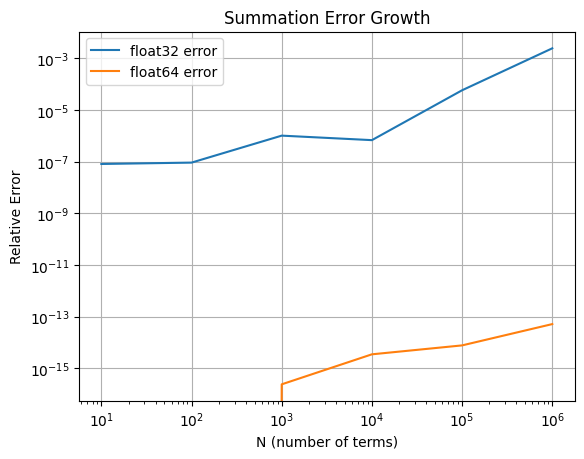

In [ ]:
#Experminet 1 : Graphing float32 vs float64 to compare Summation Error
from decimal import Decimal, getcontext
import numpy as np, matplotlib.pyplot as plt
getcontext().prec = 50  # high-prec reference
N = 1_000_000
exact = float(sum(Decimal(1)/Decimal(k) for k in  range(1,N+1)))

s32 = np.float32(0);
s64 = np.float64(0)
for k in range(1, N+1):
    s32 += np.float32(1.0/k)
    s64 += np.float64(1.0/k)

err32 = abs(s32 - exact) / exact
err64 = abs(s64 - exact) / exact
print(f'float32 rel error: {err32:.3e}')
print(f'float64 rel error: {err64:.3e}')

def compute_errors(N):
    exact = float(sum(Decimal(1)/Decimal(k) for k in range(1, N+1)))

    s32 = np.float32(0)
    s64 = np.float64(0)

    for k in range(1, N+1):
        s32 += np.float32(1.0/k)
        s64 += np.float64(1.0/k)

    err32 = abs(s32 - exact) / exact
    err64 = abs(s64 - exact) / exact

    return err32, err64


def generate_data(N_values):
    err32_list = []
    err64_list = []

    for N in N_values:
        e32, e64 = compute_errors(N)
        err32_list.append(e32)
        err64_list.append(e64)

    return err32_list, err64_list


import matplotlib.pyplot as plt

def plot_errors(N_values, err32, err64):
    plt.figure()

    plt.plot(N_values, err32, label='float32 error')
    plt.plot(N_values, err64, label='float64 error')

    plt.xscale('log')
    plt.yscale('log')

    plt.xlabel('N (number of terms)')
    plt.ylabel('Relative Error')
    plt.title('Summation Error Growth')

    plt.legend()
    plt.grid(True)
    plt.show()


# Run plotting
N_values = [10, 100, 1000, 10000, 100000, 1000000]
err32, err64 = generate_data(N_values)
plot_errors(N_values, err32, err64)

## Observation
### Experiment 1

### Experiment 2

The manually computed epsilon decreases step byy step until adding it to 1 no lon
changes the result.
Once this limit is reached, the last effective epsilon value is returned, representing
machine epsilon.
•For both float32 and loat64:
• The manual epsilon is nearly identical to np.finfo(dtype).eps
• The values also closely match the theoreticatepsilon 2-
• Itis observed that
flort32 produces a larger epsilon (-10")
flort64 produces a much smaller epsilon (-1015
• This shows that floats4 can represent much finer differences between numbers
than float32.

### Experiment 3
• For relatively larger values (eg. z = 10-
•Both np.log(1.0 + x) (naive) and np.logip(*) (stable) produce very small
errors
• As z becomes extremely small (e.g. 10-10, 10-1b
• The naive method's error increases significanty
• The stable method remains highly accurate
• Atz= 10-15,
• The naive method shows a large relative error (-11%)
• The stable method's error is close to zero
• This happens because:
• In 1.0+ *, whenz is very smal, it gets lost due to rounding
This leads to loss of significant di
cancellation error)


### Experiment 4

When summing 0.1 repeatedly using float32, the naive summation produces a noticeable error.

This error arises because:
0.1 cannot be represented exactly in binary

Small rounding errors accumulate over many additions (10 million times)

The Kahan summation algorithm significantly reduces this error by compensating for lost low-order bits during each addition.

The result from Kahan summation is much closer to the theoretical value compared to the naive method.

The reference result using math.fsum (higher precision) confirms that:

Kahan’s result is very close to the “true” sum

The naive method deviates the most

The printed accuracy comparison shows that:

Kahan summation is many times more accurate than naive summation

## Conclusion

### Experiment 1

### Experiment 2
• The manually computed machine epsilon closely matches the values obtained from
nunpy (np.finfo dtype) .eps ) for both float32 and Joats4.
The theoretical value 2-, where m is the number of mantissa bits, also agrees with
the computed results.
This confirms that the allgorithm used correctly determines the smallest number that,
when added to 1, produces a distinguishable result in floating-point arithmetic.
• It is observed that:
float32 has a larger machine epsilon, indicating lower precision
• float64 has a smaller machine epsilon, indicating higher precision
• The experiment verifies that machine epsilon depends on the number of bits used to
represent the mantissa, and therefore determines the precision limit of a floating-
point type.


### Experiment 3
• The experiment demonstrates the effect of catastrophic cancellation in numerical
computations.

The naive computation log(1 + ) becomes inaccurate for very small z because the
addition 1 +z loses precision before the logarithm is applied.

• The function np.loglp(:) avoids this issue by using a numerically stable algorithm
designed for small values of z.

• The results confirm that
Mathematically equivalent expressions can produce vastly different numerical
accuracy depending on how they are computed.

• Therefore, for small values of z, it is essential to use specialized numerical functions
(like logip) to maintain accuracy.

### Experiment 4

The experiment demonstrates that naive summation is highly susceptible to accumulated floating-point errors, especially when adding many inexact values.

The Kahan summation algorithm improves accuracy by tracking and correcting the small errors lost during each step.

Compared to the naive approach, Kahan summation produces results that are significantly closer to the true value, even when using low precision (float32).

The comparison with math.fsum confirms that Kahan summation is a reliable and efficient method for reducing numerical error.

This experiment highlights that:

Algorithm choice is just as important as data type in numerical computing.

Therefore, for large-scale summations or sensitive computations, numerically stable algorithms like Kahan summation should be preferred.